 3 step 

 - ask the story
 - match the chart

In [1]:
def say_hallo():
    print(" hello")



say_hallo()

 hello


In [2]:
def greet(name):
    print("hello",name)


greet("Sagar")
greet("hdfhh")

hello Sagar
hello hdfhh


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
import pandas as pd
import numpy as np



df = pd.read_csv("vgsales.csv")

df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Univarient Analysis

### categorical

In [5]:
df['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [6]:
df['Genre'].value_counts()

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Strategy         681
Puzzle           582
Name: count, dtype: int64

### Barchart  - (matplot)

In [7]:
 x_bar=df['Genre'].value_counts().index

In [8]:
y_bar=df['Genre'].value_counts().values

<BarContainer object of 12 artists>

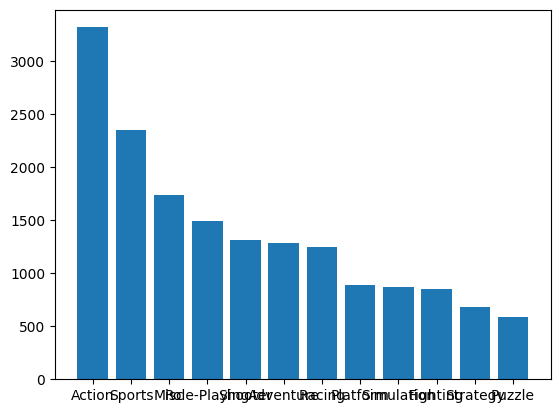

In [9]:
plt.bar(x_bar, y_bar)

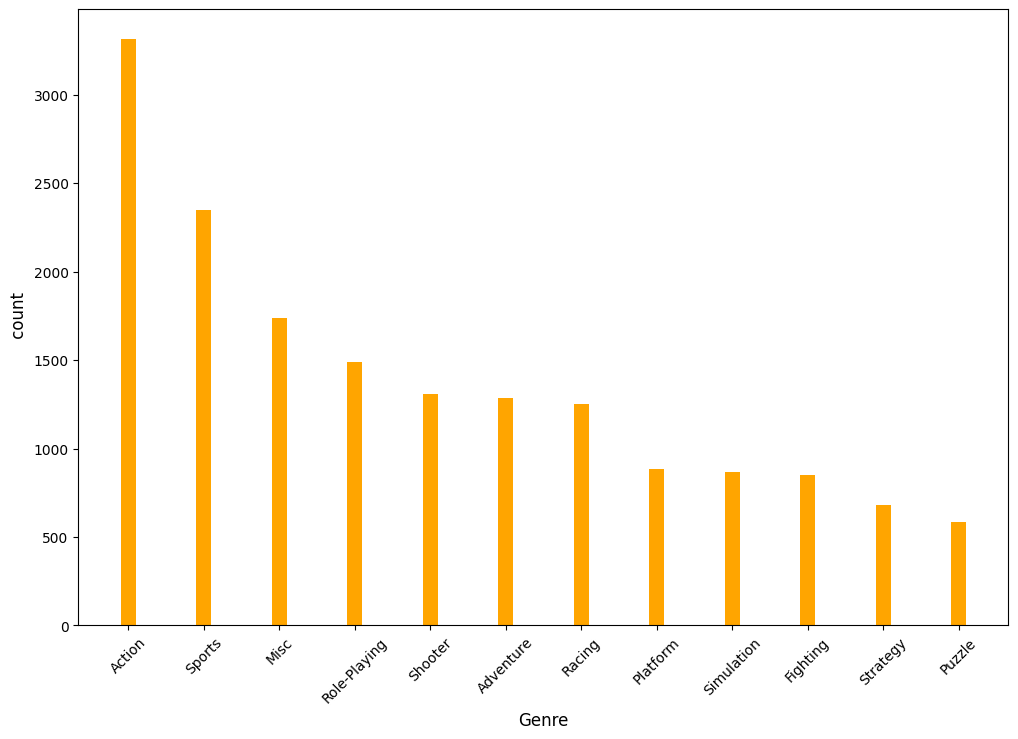

In [10]:
# size - figure

plt.figure(figsize=(12,8))
plt.bar(x_bar,y_bar, width=0.2, color='orange')
plt.xticks(rotation=45, fontsize=10)
plt.xlabel("Genre", fontsize=12)
plt.ylabel(" count", fontsize=12)
plt.show()

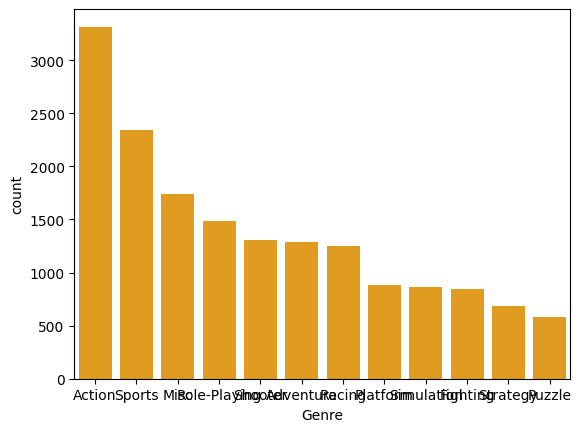

In [11]:
# seaborn

sns.countplot(data=df, x='Genre', order=df['Genre'].value_counts().index, color='orange')
plt.show()

In [12]:
# proportion / percentage ==> pie chart  (only in matplotlib)


region_sales = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]

region_sales

,NA_Sales,EU_Sales,JP_Sales,Other_Sales
0,41.49,29.02,3.77,8.46
1,29.08,3.58,6.81,0.77
2,15.85,12.88,3.79,3.31
3,15.75,11.01,3.28,2.96
4,11.27,8.89,10.22,1.00
...,...,...,...,...
16593,0.01,0.00,0.00,0.00
16594,0.01,0.00,0.00,0.00
16595,0.00,0.00,0.00,0.00
16596,0.00,0.01,0.00,0.00


In [13]:
region_sales=region_sales.T.sum(axis="columns")
region_sales

NA_Sales       4392.95
EU_Sales       2434.13
JP_Sales       1291.02
Other_Sales     797.75
dtype: float64

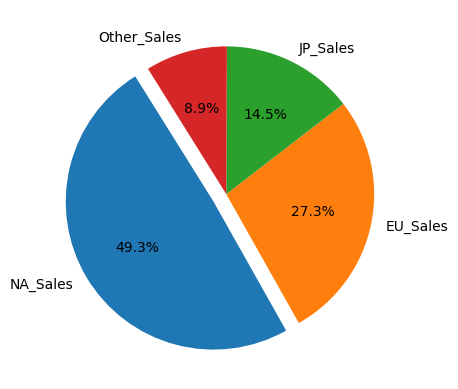

In [14]:
# pie chart

plt.pie(region_sales, labels=region_sales.index,startangle=122,explode=(0.1,0,0,0), autopct='%1.1f%%' )
plt.show()

In [15]:
sales_data = df[['NA_Sales','EU_Sales','JP_Sales','Other_Sales']]

In [16]:
# sales_data.value_counts().plot(kind='pie',
#                              autopct='%1.1f%%')
# plt.show()

In [17]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


### numerical column

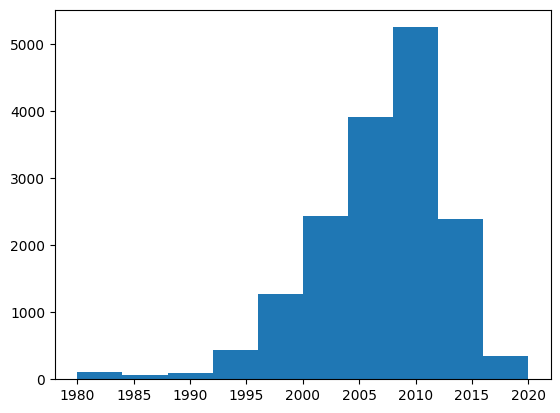

In [19]:
# histplot - matplotlib


plt.hist(data=df, x='Year')
plt.show()



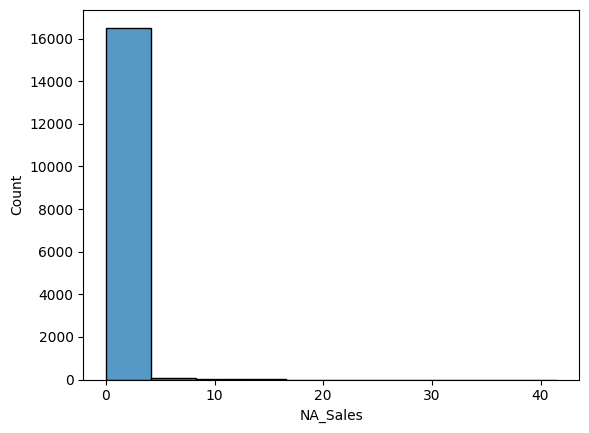

In [23]:
# seaborn

sns.histplot(data=df, x='NA_Sales', bins=10)
plt.show()

<Axes: xlabel='NA_Sales', ylabel='Density'>

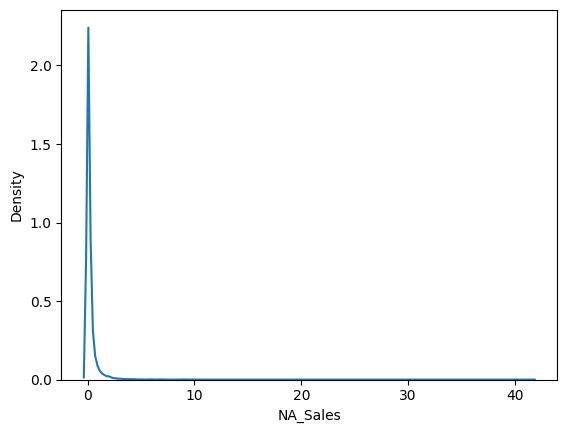

In [24]:
sns.kdeplot(data=df, x='NA_Sales')

In [25]:
df['NA_Sales'].skew()

np.float64(18.799627403792297)

<Axes: xlabel='Global_Sales'>

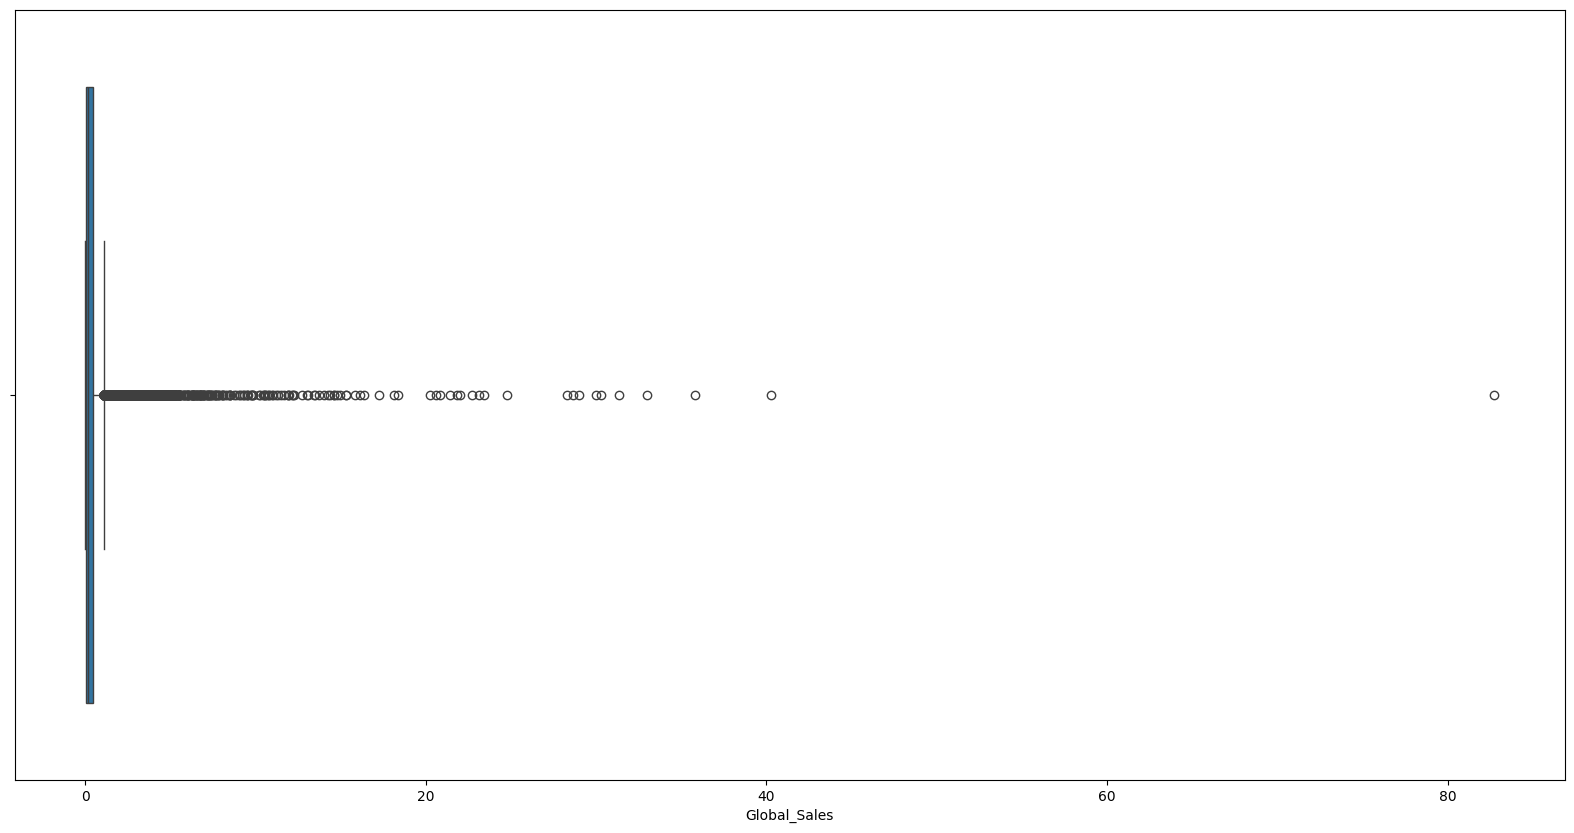

In [30]:
# boxplot
plt.figure(figsize=(20,10))
sns.boxplot(data=df, x='Global_Sales')

## Bivarient Analysis

### Line plot -  for the time data

In [31]:
df['Genre'].unique()

array(['Sports', 'Platform', 'Racing', 'Role-Playing', 'Puzzle', 'Misc',
       'Shooter', 'Simulation', 'Action', 'Fighting', 'Adventure',
       'Strategy'], dtype=object)

In [32]:
a= df.loc[df['Genre']== 'Sports']

In [33]:
a.shape

(2346, 11)

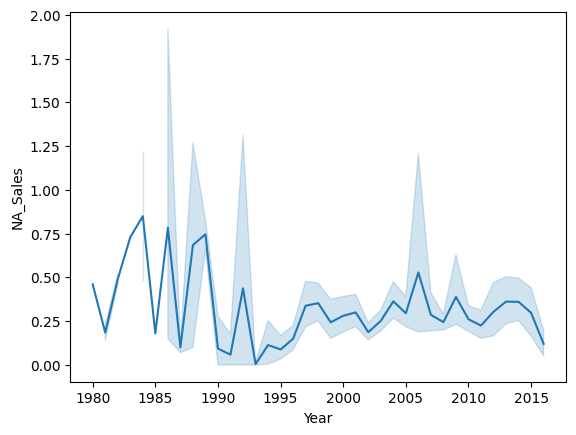

In [36]:
sns.lineplot(data = a, x='Year', y='NA_Sales')
plt.show()

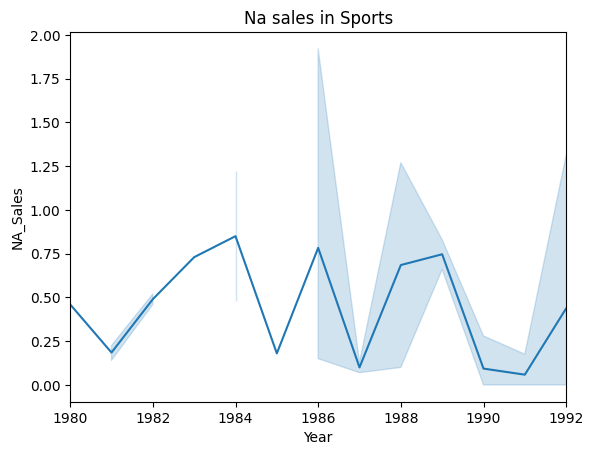

In [38]:
sns.lineplot(data = a, x='Year',y='NA_Sales')
plt.title("Na sales in Sports")
plt.xlim(left= 1980, right=1992)
plt.show()

In [39]:
# two sales in oneplot

b = df.loc[df['Genre']== "Adventure"]

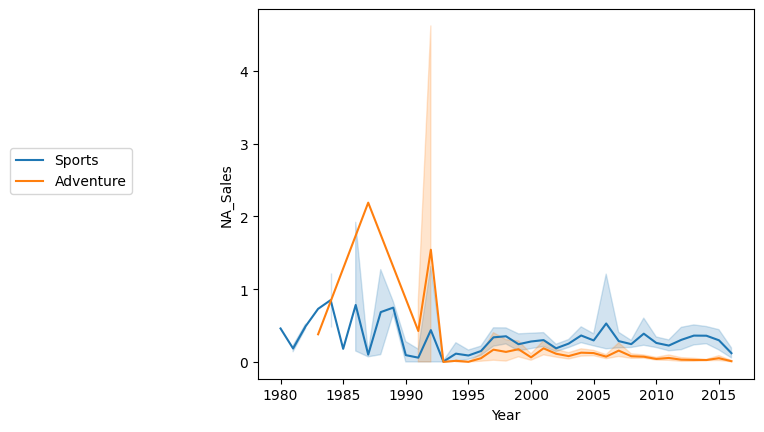

In [42]:
sns.lineplot(data=a, x="Year",y="NA_Sales", label='Sports')
sns.lineplot(data=b, x= "Year", y='NA_Sales', label='Adventure')
plt.legend(loc=(-0.5,0.5))


## Scatter plot - use for numeric - numeric relationship

In [45]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


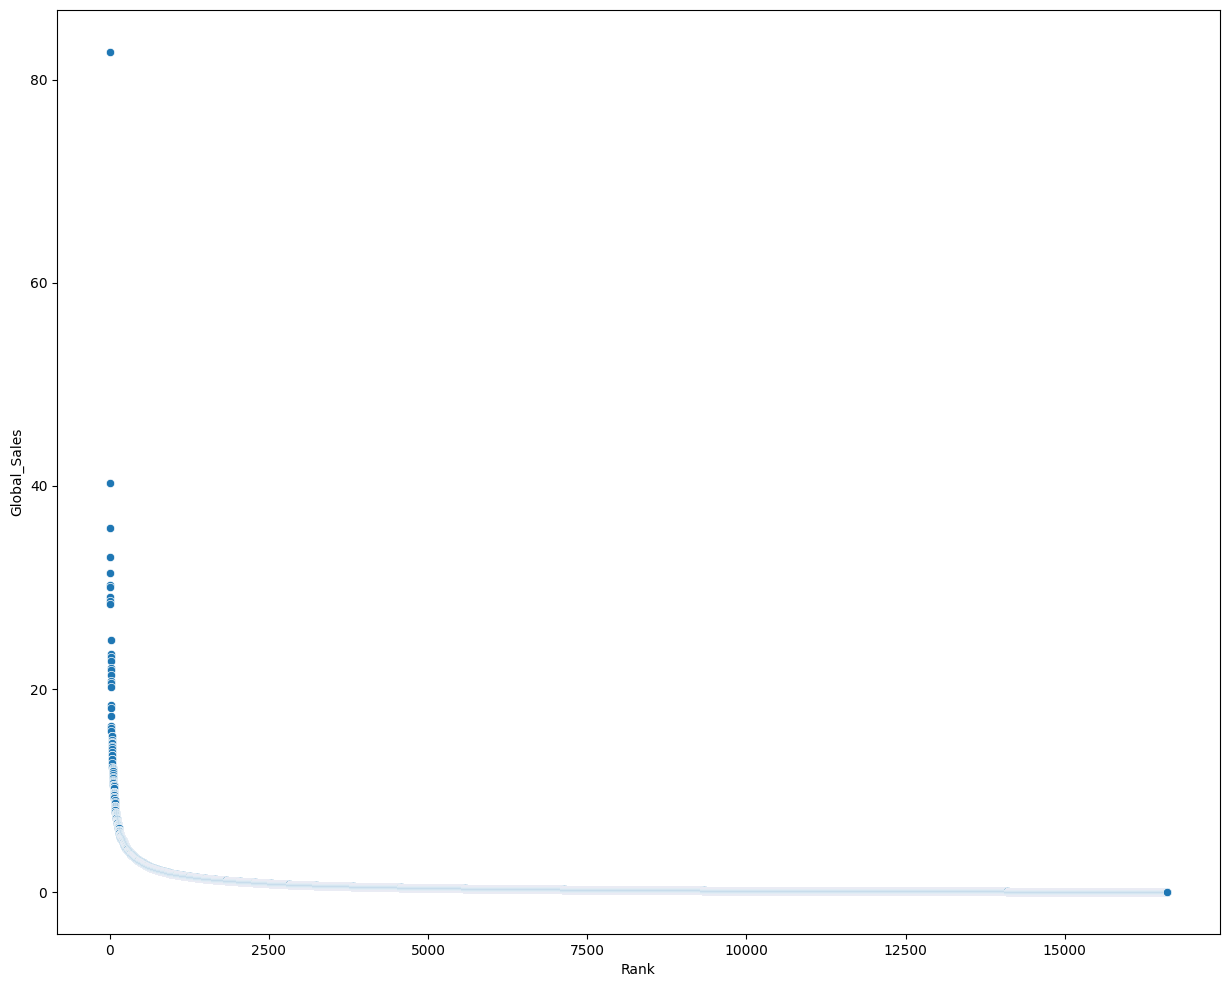

In [50]:
plt.figure(figsize=(15,12))
sns.scatterplot(data=df, x='Rank', y='Global_Sales')
plt.show()

## Category - Category

### Dodged countplot  --- if you want the total count and also want to compare 
### staked countplot  ---  if you want to only compare the category

In [60]:


top_3_pub=df['Publisher'].value_counts().index[:3]
top_3_pub 

Index(['Electronic Arts', 'Activision', 'Namco Bandai Games'], dtype='object', name='Publisher')

In [61]:
top_3_genre = df['Genre'].value_counts().index[:3]
top_3_genre

Index(['Action', 'Sports', 'Misc'], dtype='object', name='Genre')

In [63]:
top_3_plat = df['Platform'].value_counts().index[:3]
top_3_plat

Index(['DS', 'PS2', 'PS3'], dtype='object', name='Platform')

In [66]:
### top 3 data which iclude in  top 3 plat , pub and gnre

top_3_data = df.loc[(df['Genre'].isin(top_3_genre) & (df['Platform'].isin(top_3_plat) & (df['Publisher'].isin(top_3_pub))))]

In [67]:
top_3_data

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
82,83,FIFA Soccer 13,PS3,2012.0,Action,Electronic Arts,1.06,5.05,0.13,2.01,8.24
112,113,FIFA 14,PS3,2013.0,Sports,Electronic Arts,0.78,4.32,0.07,1.73,6.90
121,122,FIFA 12,PS3,2011.0,Sports,Electronic Arts,0.84,4.32,0.11,1.42,6.69
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
199,200,FIFA Soccer 11,PS3,2010.0,Sports,Electronic Arts,0.60,3.29,0.06,1.13,5.08
...,...,...,...,...,...,...,...,...,...,...,...
16102,16105,Tobidase! Kagaku-kun Chikyuu Daitanken! Nazo n...,DS,2011.0,Misc,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01
16127,16130,Madden NFL 13,PS3,2012.0,Sports,Electronic Arts,0.00,0.01,0.00,0.00,0.01
16215,16218,Tsukigime Ranko's Longest Day,PS3,2014.0,Action,Namco Bandai Games,0.00,0.01,0.00,0.00,0.01
16523,16526,Style Book: Cinnamoroll,DS,2006.0,Misc,Namco Bandai Games,0.00,0.00,0.01,0.00,0.01


<Axes: xlabel='Publisher', ylabel='count'>

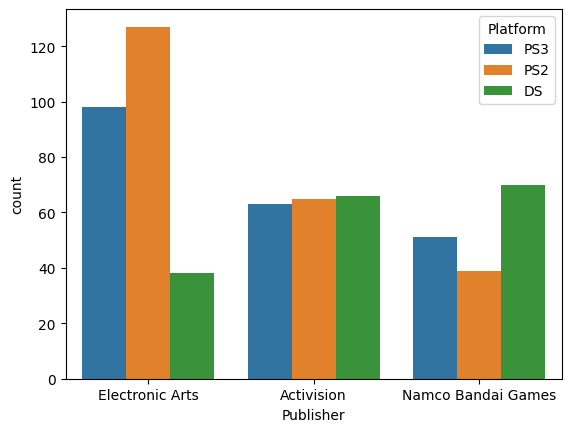

In [69]:
# dodged countplot

sns.countplot(data = top_3_data, hue='Platform', x="Publisher")

In [74]:
# staked countplot

# pivot table

df_stacked_plt = pd.crosstab(index=top_3_data['Publisher'], columns = top_3_data['Platform'])
df_stacked_plt

Platform,DS,PS2,PS3
Publisher,,,
Activision,66,65,63
Electronic Arts,38,127,98
Namco Bandai Games,70,39,51


<Axes: xlabel='Publisher'>

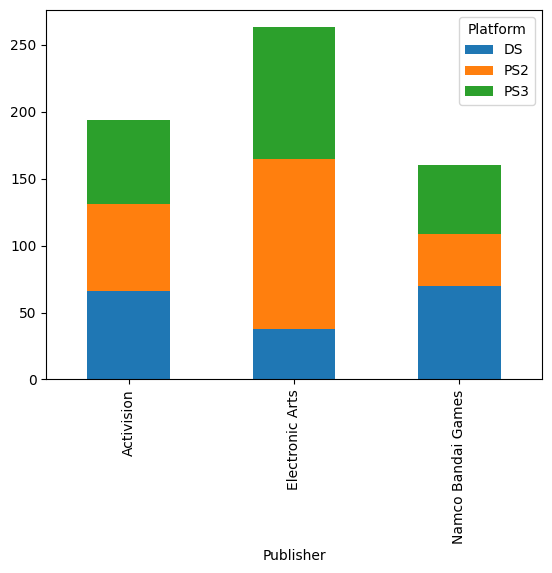

In [76]:
df_stacked_plt.plot(kind='bar', stacked=True)

### category - numeric  ===> boxplot

<Axes: xlabel='Publisher', ylabel='Global_Sales'>

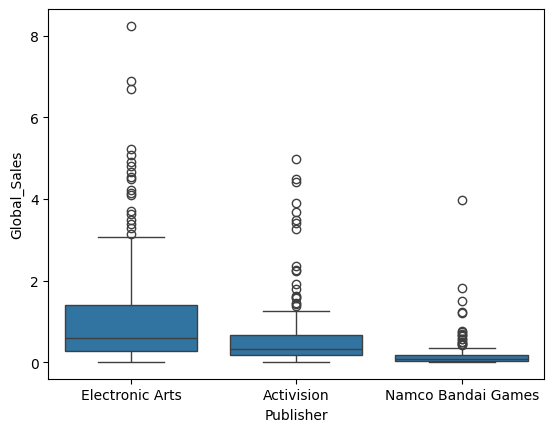

In [77]:
sns.boxplot(data = top_3_data, x ="Publisher", y="Global_Sales")

## Multivarient Analysis

### Heatmap   -- -- relation between diff num variables


In [81]:
top_3_data_num = top_3_data.select_dtypes(include='number')

In [82]:
top_3_data_num

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
82,83,2012.0,1.06,5.05,0.13,2.01,8.24
112,113,2013.0,0.78,4.32,0.07,1.73,6.90
121,122,2011.0,0.84,4.32,0.11,1.42,6.69
179,180,NaN,4.26,0.26,0.01,0.71,5.23
199,200,2010.0,0.60,3.29,0.06,1.13,5.08
...,...,...,...,...,...,...,...
16102,16105,2011.0,0.00,0.00,0.01,0.00,0.01
16127,16130,2012.0,0.00,0.01,0.00,0.00,0.01
16215,16218,2014.0,0.00,0.01,0.00,0.00,0.01
16523,16526,2006.0,0.00,0.00,0.01,0.00,0.01


<Axes: >

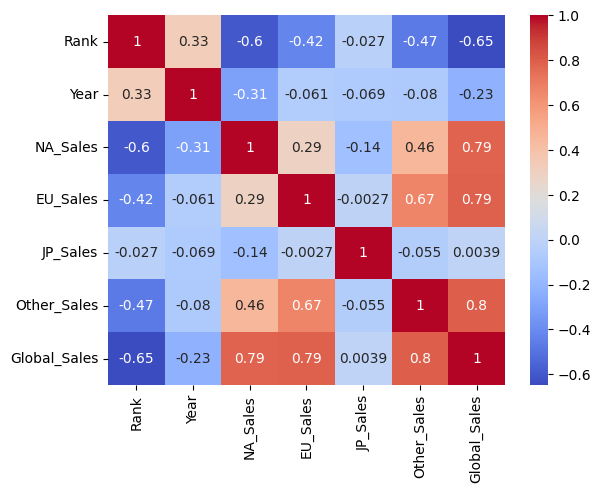

In [86]:
sns.heatmap(top_3_data_num.corr(), annot=True, cmap="coolwarm")

### Pairplot ---- to display all num variable relationship and distribution

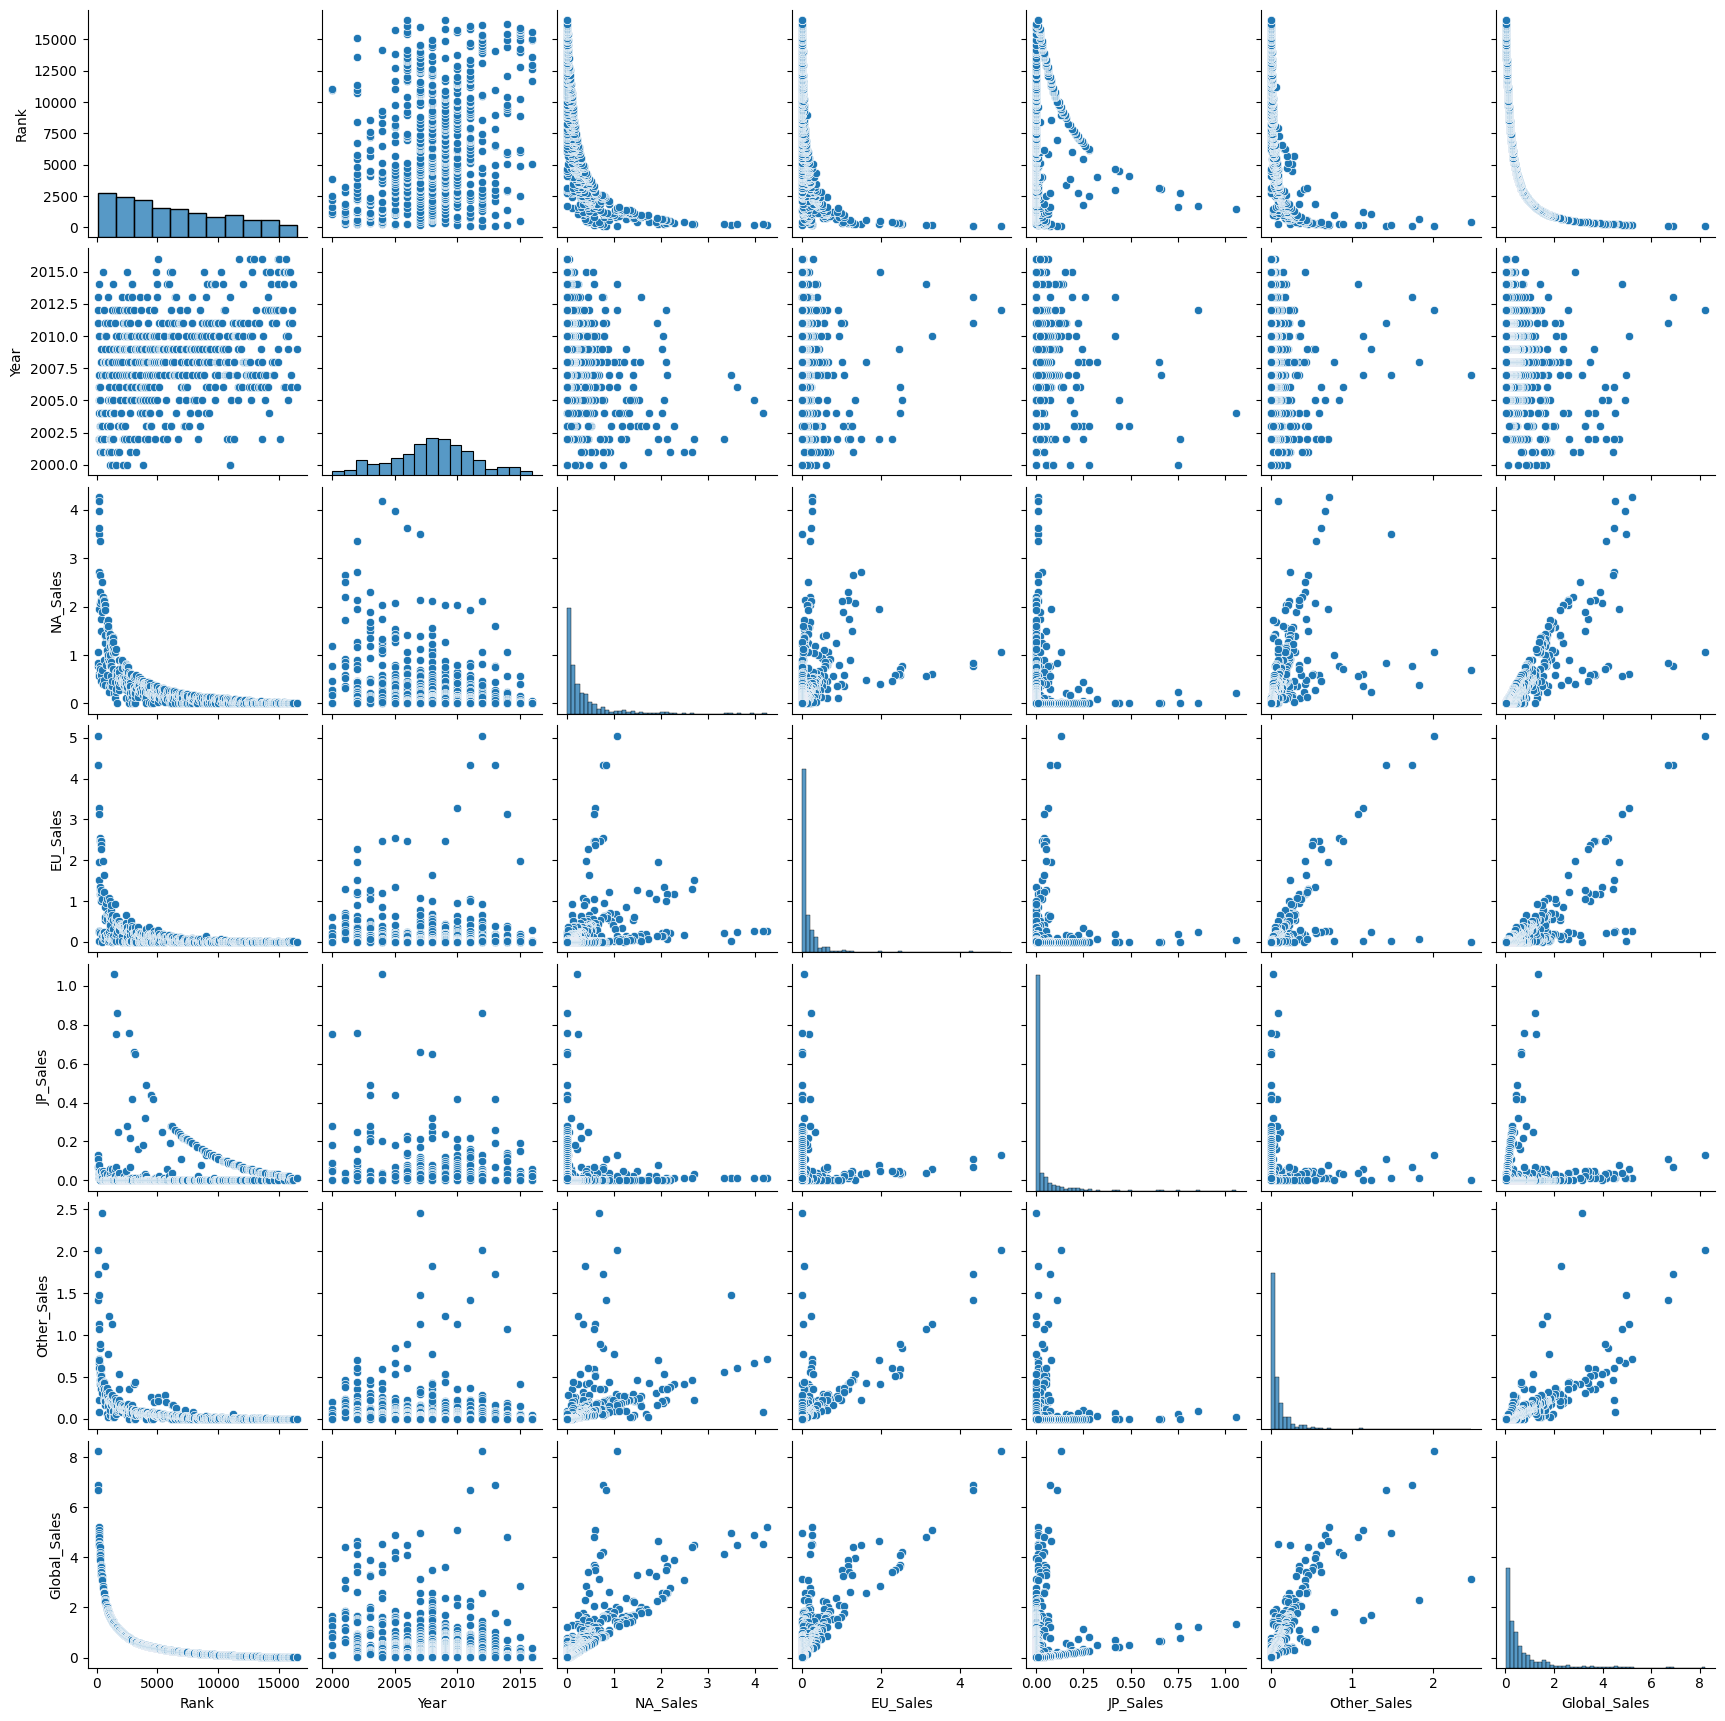

In [88]:
sns.pairplot(top_3_data)